# Notebook which uses SAM3 with SAM2 tracker
Based on https://huggingface.co/docs/transformers/model_doc/sam3_video

In [1]:
from transformers import Sam3VideoModel, Sam3VideoProcessor
import torch

In [2]:
model = Sam3VideoModel.from_pretrained("facebook/sam3", device_map="auto")
processor = Sam3VideoProcessor.from_pretrained("facebook/sam3")

Loading weights:   0%|          | 0/1797 [00:00<?, ?it/s]

In [53]:
import glob
import os
from PIL import Image
import numpy as np
import torch

# 1. Pfade sammeln und sortieren
video_path = "./videos/frames"
video_frames_paths = glob.glob(os.path.join(video_path, "*.jpg"))
video_frames_paths.sort(key=lambda p: int(os.path.splitext(os.path.basename(p))[0]))

# 2. BILDER MANUELL LADEN (Wichtig!)
# Wir laden jedes Bild als PIL Image oder Numpy Array
video_frames = [np.array(Image.open(f)) for f in video_frames_paths]

In [54]:
import torch

# Prüfen, ob eine NVIDIA GPU verfügbar ist, sonst CPU nutzen
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Benutztes Gerät: {device}")

Benutztes Gerät: cuda


In [55]:
# Initialize video inference session
inference_session = processor.init_video_session(
    video=video_frames,
    inference_device=device,
    processing_device="cpu",
    video_storage_device="cpu",
)

# Add text prompt to detect and track objects
text = "fish"
inference_session = processor.add_text_prompt(
    inference_session=inference_session,
    text=text,
)

In [56]:
# Process all frames in the video
outputs_per_frame = {}
# Pass show_progress_bar=True to display a tqdm progress bar.
for model_outputs in model.propagate_in_video_iterator(
    inference_session=inference_session, max_frame_num_to_track=50
):
    processed_outputs = processor.postprocess_outputs(inference_session, model_outputs)
    outputs_per_frame[model_outputs.frame_idx] = processed_outputs
    print("frame bearbeitet")

print(f"Processed {len(outputs_per_frame)} frames")

# Access results for a specific frame
frame_0_outputs = outputs_per_frame[0]
print(f"Detected {len(frame_0_outputs['object_ids'])} objects")
print(f"Object IDs: {frame_0_outputs['object_ids'].tolist()}")
print(f"Scores: {frame_0_outputs['scores'].tolist()}")
print(f"Boxes shape (XYXY format, absolute coordinates): {frame_0_outputs['boxes'].shape}")
print(f"Masks shape: {frame_0_outputs['masks'].shape}")

frame bearbeitet
frame bearbeitet
frame bearbeitet
frame bearbeitet
frame bearbeitet
Processed 5 frames
Detected 23 objects
Object IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Scores: [0.6418640613555908, 0.6134158372879028, 0.5404397249221802, 0.79698246717453, 0.910796582698822, 0.5481303930282593, 0.5378202795982361, 0.7042880058288574, 0.7916370034217834, 0.6602087616920471, 0.5127103328704834, 0.5467374920845032, 0.7833138704299927, 0.5781519412994385, 0.7466901540756226, 0.7784187197685242, 0.8824855089187622, 0.8836758136749268, 0.8973228335380554, 0.9085259437561035, 0.6209456920623779, 0.56644606590271, 0.8762494921684265]
Boxes shape (XYXY format, absolute coordinates): torch.Size([23, 4])
Masks shape: torch.Size([23, 480, 853])


In [57]:
outputs_per_frame[1].keys()

dict_keys(['object_ids', 'scores', 'boxes', 'masks', 'prompt_to_obj_ids'])

In [58]:
outputs_per_frame[1]['prompt_to_obj_ids']

{'fish': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22]}

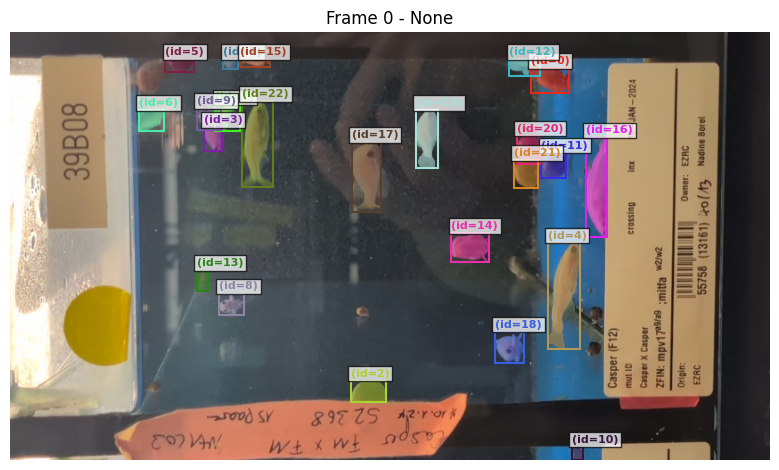

Frame 1 gesäubert und in 853x480 gespeichert.


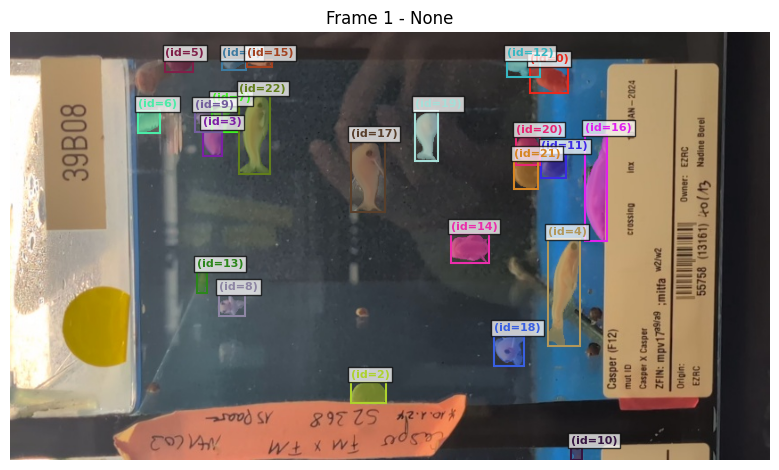

Frame 2 gesäubert und in 853x480 gespeichert.


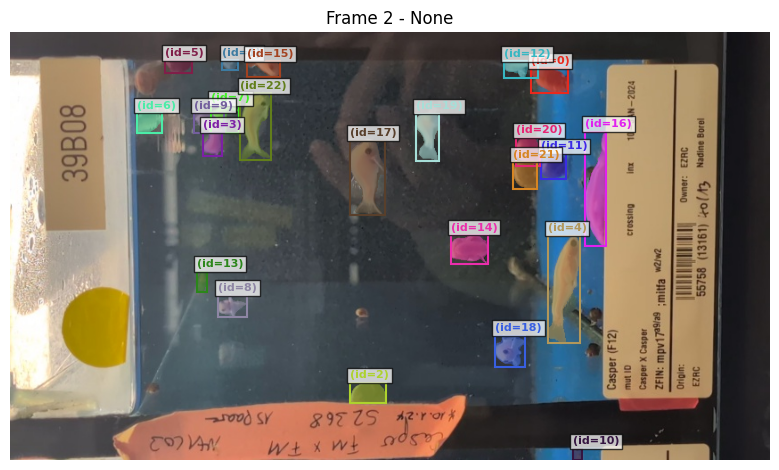

Frame 3 gesäubert und in 853x480 gespeichert.


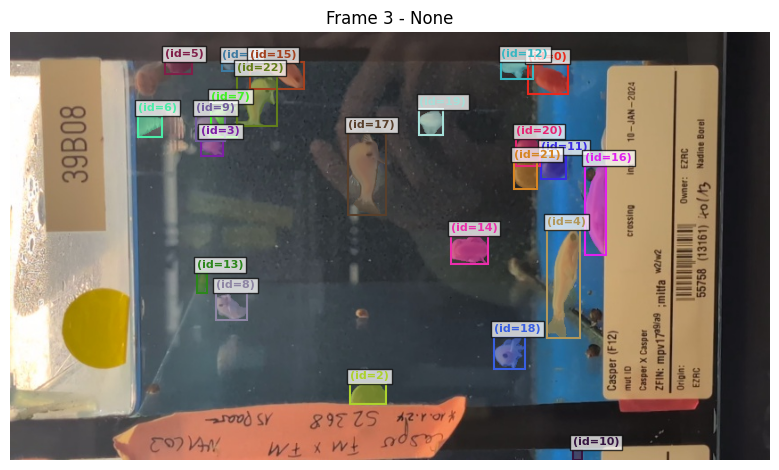

Frame 4 gesäubert und in 853x480 gespeichert.


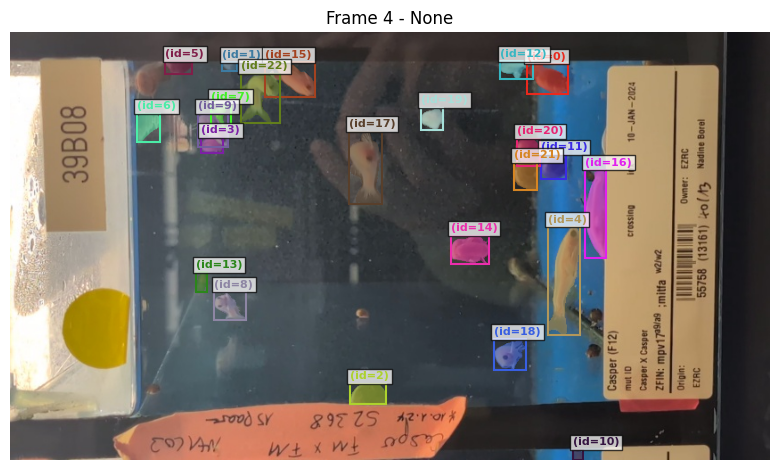

Frame 5 gesäubert und in 853x480 gespeichert.


In [59]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image
from scipy.ndimage import label # Zum Finden zusammenhängender Flächen

def filter_largest_component(mask):
    """Behält nur die größte zusammenhängende Fläche einer Maske und löscht Rauschen."""
    if not mask.any(): return mask
    structure = np.ones((3, 3), dtype=int) # Definiert Nachbarschaft (8-Wege)
    labeled, n_components = label(mask, structure)
    if n_components <= 1: return mask
    
    # Zähle Pixel pro Fläche und finde die größte (außer Hintergrund 0)
    component_sizes = np.bincount(labeled.ravel())
    largest_idx = component_sizes[1:].argmax() + 1
    return labeled == largest_idx

def get_tight_box(mask_np):
    """Berechnet die XYXY-Box für eine gesäuberte Maske."""
    coords = np.argwhere(mask_np)
    if coords.size == 0: return [0, 0, 0, 0]
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return [float(x_min), float(y_min), float(x_max), float(y_max)]

output_dir = "./outputs"
os.makedirs(output_dir, exist_ok=True)

for i in sorted(outputs_per_frame.keys()):
    out = outputs_per_frame[i]
    with Image.open(video_frames_for_vis[i]) as img:
        orig_w, orig_h = img.size
    
    # 1. Hochskalieren auf Originalgröße
    masks_raw = out["masks"].cpu()
    masks_resized = F.interpolate(masks_raw.unsqueeze(1).float(), size=(orig_h, orig_w), mode="bilinear").squeeze(1) > 0.0
    
    # 2. JEDE MASKE SÄUBERN
    cleaned_masks = []
    new_boxes = []
    obj_ids = out["object_ids"].cpu().tolist()
    
    for m_idx in range(len(masks_resized)):
        mask_np = masks_resized[m_idx].numpy()
        # Nur das größte zusammenhängende Stück behalten (der Fisch)
        cleaned_mask_np = filter_largest_component(mask_np)
        cleaned_masks.append(torch.from_numpy(cleaned_mask_np))
        
        # Neue Box aus der gesäuberten Maske berechnen
        new_boxes.append(get_tight_box(cleaned_mask_np))
    
    # 3. Daten übersetzen
    translated_out = {
        "out_obj_ids": torch.tensor(obj_ids),
        "out_binary_masks": torch.stack(cleaned_masks),
        "out_boxes": torch.tensor(new_boxes)
    }

    # 4. Pixelgenaue Visualisierung (Originalauflösung)
    plt.close("all")
    my_dpi = 100
    fig_w, fig_h = orig_w / my_dpi, orig_h / my_dpi
    
    prepared_output = prepare_masks_for_visualization({i: translated_out})
    
    visualize_formatted_frame_output(
        i, 
        video_frames_for_vis, 
        outputs_list=[prepared_output],
        titles=[None],
        figsize=(fig_w, fig_h)
    )

    # Ränder entfernen für exakte Auflösung
    ax = plt.gca()
    ax.set_axis_off()
    plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
    
    file_name = f"output{i + 1:04d}.jpg"
    plt.savefig(os.path.join(output_dir, file_name), dpi=my_dpi, pad_inches=0)
    plt.close()
    
    print(f"Frame {i+1} gesäubert und in {orig_w}x{orig_h} gespeichert.")